## Practice Lecture 17 - Deep Neural Networks
In this lab we will use Deep Neural Networks for classification and regression. \
Based on Chapter 10 from Aurelien Geron's book, Hands-on Machine Learning with Scikit-Learn Keras & Tensorflow.\
Original code examples from book in github [here](https://github.com/ageron/handson-ml2)

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/dtrad/geoml_course/blob/master/Practice17_DNN.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
except Exception:
    pass

# TensorFlow ≥2.0 is required
import tensorflow as tf
assert tf.__version__ >= "2.0"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt


### Exercise 1: Classification with the Perceptron
Use scikit-learn to create a perceptron to classify the iris data set (single classification).\
Convert the data to binary classification (y==0 True, all others False).\
Use the Percetron in sklearn to obtain the values of the line that separates the two classes and plot them in one graphics


In [2]:
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris

In [3]:
iris = load_iris()
X = iris.data[:,(2,3)]
y = iris.target

In [4]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [5]:
print(y.shape)
print(y.dtype)
print(y)

(150,)
int64
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [6]:
y2 = (iris.target == 0).astype(np.int)

In [7]:
print(y2.dtype)
print(y2)

int64
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


In [8]:
pct=Perceptron()
pct.fit(X,y2)

Perceptron(alpha=0.0001, class_weight=None, early_stopping=False, eta0=1.0,
           fit_intercept=True, max_iter=1000, n_iter_no_change=5, n_jobs=None,
           penalty=None, random_state=0, shuffle=True, tol=0.001,
           validation_fraction=0.1, verbose=0, warm_start=False)

The coefficients w[0] and w[1] are in "\*.coef_". 

(1, 2)
(1,)
(150, 2)
(150,)
[[-0.7 -1.2]]
[2.]
-0.5833333333333338
1.6666666666666665


Text(0, 0.5, 'X2')

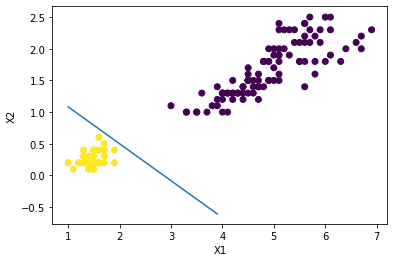

In [9]:
plt.figure()
plt.scatter(X[:,0],X[:,1],c=y2)
a=pct.coef_
b=pct.intercept_
print(a.shape)
print(b.shape)
print(X.shape)
print(y.shape)
print(a)
print(b)
m=-(a[0,0]/a[0,1])
b=-(b[0]/a[0,1])
print(m),print(b)
x=np.arange(1,4,0.1)
plt.plot(x,m*x+b)
plt.xlabel('X1')
plt.ylabel('X2')


### Exercise 2: Sequential Neural Network with MNIST
Build a classifier with keras for the MNIST data set.\
You need to convert the integer values that represent each pixel to floats between 0-1

In [10]:
from tensorflow import keras
import tensorflow as tf

In [11]:
mnist = keras.datasets.mnist

In [15]:
(X,y),(Xt,yt) = mnist.load_data()
X=X/255.
Xt=Xt/255.
Xv=X[50001:]
yv=y[50001:]
X=X[:50000]
y=y[:50000]


In [16]:
print(X.shape,y.shape,Xv.shape,yv.shape,Xt.shape,yt.shape)

(50000, 28, 28) (50000,) (9999, 28, 28) (9999,) (10000, 28, 28) (10000,)


5


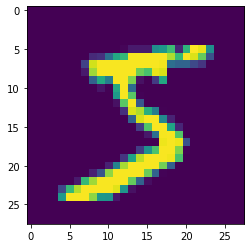

In [18]:
plt.figure()
plt.imshow(X[0])
print(y[0])

Build a sequential fully connected network. Because the output is multiclass we need "softmax" in output.

In [19]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28]))
model.add(keras.layers.Dense(300,activation="relu"))
model.add(keras.layers.Dense(100,activation="relu"))
model.add(keras.layers.Dense(10,activation="softmax"))

In [20]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 300)               235500    
_________________________________________________________________
dense_1 (Dense)              (None, 100)               30100     
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [21]:
# number of parameters for each layer
def nparam(ninput, nneurons):
    return (ninput+1)*nneurons
print(nparam(784,300))
print(nparam(300,100))
print(nparam(100,10))

235500
30100
1010


Use sparse_categorical_crossentropy because:
* "sparse" classes are sparse (1 in 10)
* "categorical" because classes are exclusive
* "crossentropy" used for classification 

In [22]:
model.compile(loss="sparse_categorical_crossentropy",optimizer="sgd",metrics=["accuracy"])

Passing validation data is optional but it permits to evaluate accuracy with iterations.\
The output is a class with useful information

In [23]:
niter=10
history=model.fit(X,y,epochs=niter,validation_data=(Xv,yv))

Train on 50000 samples, validate on 9999 samples
Epoch 1/10
50000/50000 [==============================] - 4s 81us/sample - loss: 0.6545 - accuracy: 0.8281 - val_loss: 0.3076 - val_accuracy: 0.9141
Epoch 2/10
50000/50000 [==============================] - 3s 69us/sample - loss: 0.3023 - accuracy: 0.9140 - val_loss: 0.2606 - val_accuracy: 0.9231
Epoch 3/10
50000/50000 [==============================] - 4s 71us/sample - loss: 0.2482 - accuracy: 0.9293 - val_loss: 0.2113 - val_accuracy: 0.9391
Epoch 4/10
50000/50000 [==============================] - 3s 69us/sample - loss: 0.2128 - accuracy: 0.9390 - val_loss: 0.1867 - val_accuracy: 0.9480
Epoch 5/10
50000/50000 [==============================] - 3s 69us/sample - loss: 0.1864 - accuracy: 0.9460 - val_loss: 0.1682 - val_accuracy: 0.9527
Epoch 6/10
50000/50000 [==============================] - 3s 69us/sample - loss: 0.1655 - accuracy: 0.9522 - val_loss: 0.1504 - val_accuracy: 0.9594
Epoch 7/10
50000/50000 [==============================] -

In [24]:
print(tf.__version__)

2.1.0


In [25]:
print(type(history))
history.params

<class 'tensorflow.python.keras.callbacks.History'>


{'batch_size': 32,
 'epochs': 10,
 'steps': 1563,
 'samples': 50000,
 'verbose': 0,
 'do_validation': True,
 'metrics': ['loss', 'accuracy', 'val_loss', 'val_accuracy']}

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


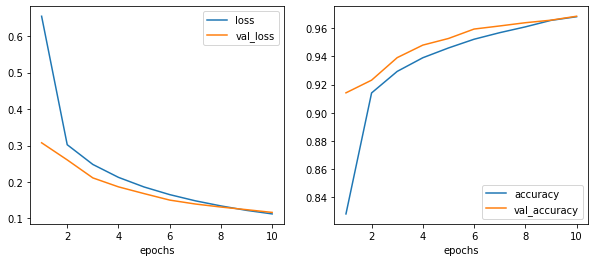

In [27]:
history.params.items
def print_history(history):
    niter=history.params['epochs']
    print(history.history.keys())
    iter=np.arange(niter)+1
    plt.figure(figsize=(10,4))
    plt.subplot(121)
    plt.plot(iter,history.history['loss'],label='loss')
    plt.plot(iter,history.history['val_loss'],label='val_loss')
    plt.xlabel('epochs')
    plt.legend()
    plt.subplot(122)
    plt.plot(iter,history.history['accuracy'],label='accuracy')
    plt.plot(iter,history.history['val_accuracy'],label='val_accuracy')
    plt.xlabel('epochs')
    plt.legend()
print_history(history)

We can evaluate how it performs in the test data set.

In [28]:
model.evaluate(Xt,yt)

10000/10000 [==============================] - 0s 47us/sample - loss: 0.1171 - accuracy: 0.9646


[0.11710388967581094, 0.9646]

In [29]:
model.evaluate(Xt[:3],yt[:3])

3/3 [==============================] - 0s 6ms/sample - loss: 0.0080 - accuracy: 1.0000


[0.007991545833647251, 1.0]

In [30]:
print(yt[:3])

[7 2 1]


(<matplotlib.axes._subplots.AxesSubplot at 0x7fcd0d813b50>,
 <matplotlib.image.AxesImage at 0x7fcd0d85d250>)

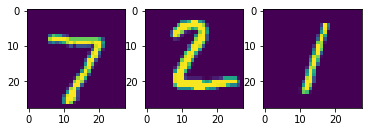

In [31]:
plt.figure()
plt.subplot(131),plt.imshow(Xt[0])
plt.subplot(132),plt.imshow(Xt[1])
plt.subplot(133),plt.imshow(Xt[2])

The evaluate method gives the most probable class. We can see probabilities for each class using predict()

In [33]:
Xnew=Xt[1:20]
ynew=yt[1:20]
yproba=model.predict(Xnew)

In [36]:
print(yproba.round(2))

[[0.   0.   1.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.99 0.   0.   0.   0.   0.   0.   0.   0.  ]
 [1.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.99 0.   0.   0.   0.   0.01]
 [0.   0.99 0.   0.   0.   0.   0.   0.01 0.   0.  ]
 [0.   0.   0.   0.   0.99 0.   0.   0.   0.01 0.  ]
 [0.   0.   0.   0.01 0.01 0.   0.   0.   0.   0.98]
 [0.   0.   0.   0.   0.   0.02 0.97 0.   0.   0.  ]
 [0.   0.   0.   0.   0.01 0.   0.   0.01 0.   0.98]
 [1.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.97 0.   0.02 0.  ]
 [0.   0.   0.   0.   0.01 0.   0.   0.   0.   0.99]
 [1.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   1.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.05 0.   0.94 0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.01 0.   0.   0.   0.   0.99]
 [0.   0.   0.   0.01 0.   0.   0.   0.99 0.   0.  ]
 [0.   0.   0.02 0.96 0.   0.   0.   0.   0.02 0.  ]
 [0.   0.   0.   0.   1.   0.   0.   0.   0.  

To see the classes we use "predict_classes". Then we can compare with the true values (labels).

In [37]:
yproba2=model.predict_classes(Xnew)
print(yproba2)

[2 1 0 4 1 4 9 6 9 0 6 9 0 1 5 9 7 3 4]


In [38]:
# labels
print(ynew)

[2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


In [39]:
# errors
print(yproba2-ynew)

[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]


We see only one sample was missclassified. We can find which was an print it.

In [40]:
print(np.argmax(yproba2-ynew))

7


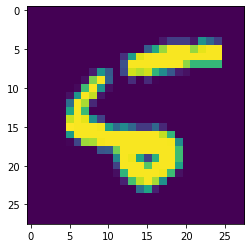

In [41]:
plt.imshow(Xnew[7])

Let us now look at the layers. Layers can be referenced by indexes or names.

In [42]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 300)               235500    
_________________________________________________________________
dense_1 (Dense)              (None, 100)               30100     
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [44]:
hidden1 = model.layers[1]
print(hidden1.name)
model.get_layer(hidden1.name) is hidden1

dense


True

We can see the weights (and biases) for each layer.

In [45]:
weights, biases = hidden1.get_weights()

In [46]:
print(weights.shape, biases.shape)

(784, 300) (300,)


In [47]:
print(weights[0,:10])
print(biases[:10])

[-0.03671434 -0.00865346 -0.01998831 -0.01900015 -0.06576359  0.00631161
  0.069831   -0.00441818  0.05716357 -0.03989924]
[ 1.0150063e-02 -5.3266734e-03 -4.4595799e-03 -4.4843146e-05
  2.3486184e-02  1.5697028e-02 -6.0807960e-03 -1.7247045e-02
 -7.9624995e-04  2.5466601e-03]


### Exercise 3: Functional API
Write the same problem as exercise 2 but using Functional API.\
The functional API looks like a series of functions connected through inputs and outputs. \
We need to define input, layers and output and then build the model as a function that connects input(s) and output(s).

In [48]:
print(X[:].flatten().shape)

(39200000,)


In [49]:
input_ = keras.layers.Input(shape=(28,28))
inputf_ = keras.layers.Flatten(input_shape=[28,28])(input_)
hidden1 = keras.layers.Dense(300, activation="relu")(inputf_)
hidden2 = keras.layers.Dense(100, activation="relu")(hidden1)
output = keras.layers.Dense(10,activation="softmax")(hidden2)
model = keras.models.Model(inputs=[input_], outputs=[output])

In [50]:
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 28, 28)]          0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_3 (Dense)              (None, 300)               235500    
_________________________________________________________________
dense_4 (Dense)              (None, 100)               30100     
_________________________________________________________________
dense_5 (Dense)              (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [51]:
model.compile(loss="sparse_categorical_crossentropy",optimizer="sgd",metrics=["accuracy"])

In [52]:
history=model.fit(X,y,epochs=10,validation_data=(Xv,yv))

Train on 50000 samples, validate on 9999 samples
Epoch 1/10
50000/50000 [==============================] - 4s 75us/sample - loss: 0.6405 - accuracy: 0.8351 - val_loss: 0.3109 - val_accuracy: 0.9132
Epoch 2/10
50000/50000 [==============================] - 3s 69us/sample - loss: 0.3057 - accuracy: 0.9138 - val_loss: 0.2576 - val_accuracy: 0.9271
Epoch 3/10
50000/50000 [==============================] - 3s 68us/sample - loss: 0.2533 - accuracy: 0.9281 - val_loss: 0.2202 - val_accuracy: 0.9377
Epoch 4/10
50000/50000 [==============================] - 3s 68us/sample - loss: 0.2189 - accuracy: 0.9378 - val_loss: 0.1964 - val_accuracy: 0.9444
Epoch 5/10
50000/50000 [==============================] - 4s 70us/sample - loss: 0.1920 - accuracy: 0.9454 - val_loss: 0.1771 - val_accuracy: 0.9505
Epoch 6/10
50000/50000 [==============================] - 3s 69us/sample - loss: 0.1701 - accuracy: 0.9517 - val_loss: 0.1582 - val_accuracy: 0.9570
Epoch 7/10
50000/50000 [==============================] -

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


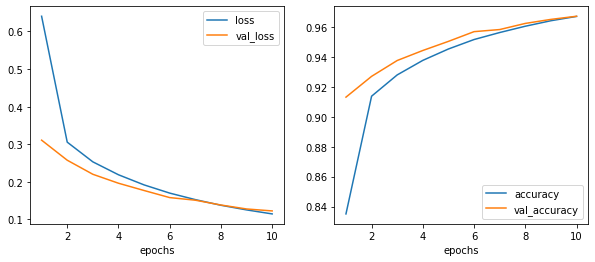

In [53]:
print_history(history)

In [54]:
history2=model.fit(X,y,epochs=3,validation_data=(Xv,yv))

Train on 50000 samples, validate on 9999 samples
Epoch 1/3
50000/50000 [==============================] - 4s 70us/sample - loss: 0.1056 - accuracy: 0.9703 - val_loss: 0.1162 - val_accuracy: 0.9678
Epoch 2/3
50000/50000 [==============================] - 3s 69us/sample - loss: 0.0975 - accuracy: 0.9724 - val_loss: 0.1122 - val_accuracy: 0.9697
Epoch 3/3
50000/50000 [==============================] - 3s 69us/sample - loss: 0.0902 - accuracy: 0.9748 - val_loss: 0.1087 - val_accuracy: 0.9698


### Exercise 4: Subclassing API
Do the same as exercise 2 but with the subclassing API.

For subclassing we need to inherit from keras.models.Model and define the layers architecture in the constructor.\
The order does not matter since we are just defining variables.\
The call method is the one that defines the dataflow from the variables defined in the class.\
All other methods are inherited from Model. The call method is not called directly but from the other methods.\
Notice that the call method is like the functional API but without defining the layers that were defined in the constructor.

In [55]:
class mnistexample(keras.models.Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.inputf = keras.layers.Flatten(input_shape=[28,28])
        self.hidden1 = keras.layers.Dense(300, activation="relu")
        self.hidden2 = keras.layers.Dense(100, activation="relu")
        self.main_output = keras.layers.Dense(10, activation="softmax")
        
    def call(self, input):
        inputf = self.inputf(input)
        hidden1 = self.hidden1(inputf)
        hidden2 = self.hidden2(hidden1)
        main_output = self.main_output(hidden2)        
        return main_output


In [56]:
# create an instance of the class
model = mnistexample()

In [57]:
# the compile method is inherited from Model the same as the others
model.compile(loss="sparse_categorical_crossentropy",optimizer="sgd",metrics=["accuracy"])

In [58]:
history=model.fit(X,y, epochs=10, validation_data=(Xv,yv))

Train on 50000 samples, validate on 9999 samples
Epoch 1/10
50000/50000 [==============================] - 4s 75us/sample - loss: 0.6292 - accuracy: 0.8393 - val_loss: 0.3084 - val_accuracy: 0.9118
Epoch 2/10
50000/50000 [==============================] - 3s 68us/sample - loss: 0.2969 - accuracy: 0.9153 - val_loss: 0.2471 - val_accuracy: 0.9306
Epoch 3/10
50000/50000 [==============================] - 3s 68us/sample - loss: 0.2445 - accuracy: 0.9308 - val_loss: 0.2146 - val_accuracy: 0.9412
Epoch 4/10
50000/50000 [==============================] - 3s 69us/sample - loss: 0.2109 - accuracy: 0.9400 - val_loss: 0.1855 - val_accuracy: 0.9509
Epoch 5/10
50000/50000 [==============================] - 3s 69us/sample - loss: 0.1856 - accuracy: 0.9472 - val_loss: 0.1706 - val_accuracy: 0.9548
Epoch 6/10
50000/50000 [==============================] - 3s 69us/sample - loss: 0.1651 - accuracy: 0.9526 - val_loss: 0.1547 - val_accuracy: 0.9592
Epoch 7/10
50000/50000 [==============================] -

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


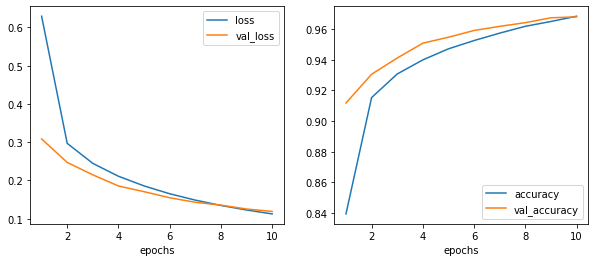

In [59]:
print_history(history)

When inquiring information from the model, the informatio looks a bit different since the shape is not available.

In [60]:
model.summary()

Model: "mnistexample"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_2 (Flatten)          multiple                  0         
_________________________________________________________________
dense_6 (Dense)              multiple                  235500    
_________________________________________________________________
dense_7 (Dense)              multiple                  30100     
_________________________________________________________________
dense_8 (Dense)              multiple                  1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [64]:
Xnew=Xt[0:20]
ynew=yt[0:20]
yproba=model.predict(Xnew)
print(yproba.round(2))

[[0.   0.   0.   0.01 0.   0.   0.   0.99 0.   0.  ]
 [0.   0.   0.99 0.01 0.   0.   0.   0.   0.   0.  ]
 [0.   0.99 0.   0.   0.   0.   0.   0.   0.   0.  ]
 [1.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.99 0.   0.   0.   0.   0.01]
 [0.   0.99 0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.99 0.   0.   0.   0.01 0.  ]
 [0.   0.   0.01 0.01 0.   0.   0.   0.   0.   0.98]
 [0.   0.   0.   0.   0.01 0.05 0.94 0.   0.   0.  ]
 [0.   0.   0.   0.   0.01 0.   0.   0.   0.   0.98]
 [1.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.99 0.   0.01 0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.99]
 [1.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   1.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.11 0.   0.88 0.   0.   0.01 0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   1.  ]
 [0.   0.   0.   0.01 0.   0.   0.   0.99 0.   0.  ]
 [0.   0.   0.02 0.96 0.   0.   0.   0.   0.01

In [65]:
print(ynew)

[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


In [66]:
# Not sure how to make the model class to inherent the predict_classes method.
#yproba2=model.predict_classes(Xnew)
#print(yproba2)
print(yproba.shape)
print(np.argmax(yproba,axis=1))

(20, 10)
[7 2 1 0 4 1 4 9 6 9 0 6 9 0 1 5 9 7 3 4]


### Exercise 3.1 (assignment 3):
Repeat the classification exercise using the following data set:

Text(0.5, 1.0, 'Coat')

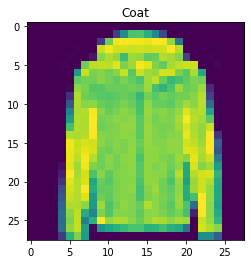

In [67]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.
plt.imshow(X_train[0])
plt.title(class_names[y_train[0]])

HINT: everything is similar to the MNIST but now the classes labels are numbers associated with the classes_names.
This dataset is harder to classify right, accuraccy will be less.

### Exercise 5 - Regression MLP
Use the california_housing data set we used earlier in the course with linear regression and compare with MLP.

When doing regression the network looks very similar but there are a few differences:
* for metrics, instead of accuracy we need "mse"
* for activation in the last layer, instead of "softmax" we need "relu" or "selu".
* for cost function, instead of "crossentropy" we need "mse" or "mae" or "huber"
Let us do some data preprocessing first.

In [68]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()

X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [69]:
print(housing.data.shape)
print(housing.data[0:2])
print(X_train[0:2,:])
print(y_train[0:2])

(20640, 8)
[[ 8.32520000e+00  4.10000000e+01  6.98412698e+00  1.02380952e+00
   3.22000000e+02  2.55555556e+00  3.78800000e+01 -1.22230000e+02]
 [ 8.30140000e+00  2.10000000e+01  6.23813708e+00  9.71880492e-01
   2.40100000e+03  2.10984183e+00  3.78600000e+01 -1.22220000e+02]]
[[-0.19397883 -1.07781319 -0.94338545  0.01485314  0.02073335 -0.57291624
   0.92926047 -1.42215523]
 [ 0.75198318 -1.868895    0.40547793 -0.23327682  1.8614649   0.20516532
  -0.91654738  1.09666969]]
[1.442 1.687]


Let us use the sequential API (alternative form from what we used above)

In [70]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(1)
])
model.compile(loss="mean_squared_error", optimizer=keras.optimizers.SGD(lr=1e-3))
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))


Train on 11610 samples, validate on 3870 samples
Epoch 1/20
11610/11610 [==============================] - 1s 89us/sample - loss: 2.2345 - val_loss: 1.0018
Epoch 2/20
11610/11610 [==============================] - 1s 64us/sample - loss: 0.7988 - val_loss: 0.7606
Epoch 3/20
11610/11610 [==============================] - 1s 64us/sample - loss: 0.6804 - val_loss: 0.6696
Epoch 4/20
11610/11610 [==============================] - 1s 63us/sample - loss: 0.6278 - val_loss: 0.6070
Epoch 5/20
11610/11610 [==============================] - 1s 65us/sample - loss: 0.5893 - val_loss: 0.5541
Epoch 6/20
11610/11610 [==============================] - 1s 64us/sample - loss: 0.5579 - val_loss: 0.5170
Epoch 7/20
11610/11610 [==============================] - 1s 63us/sample - loss: 0.5345 - val_loss: 0.4983
Epoch 8/20
11610/11610 [==============================] - 1s 67us/sample - loss: 0.5171 - val_loss: 0.4846
Epoch 9/20
11610/11610 [==============================] - 1s 64us/sample - loss: 0.5023 - val_l

In [71]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_9 (Dense)              (None, 30)                270       
_________________________________________________________________
dense_10 (Dense)             (None, 1)                 31        
Total params: 301
Trainable params: 301
Non-trainable params: 0
_________________________________________________________________


Since we don't have "accuracy" we can't use print_history(history). Let us define a new one.

dict_keys(['loss', 'val_loss'])


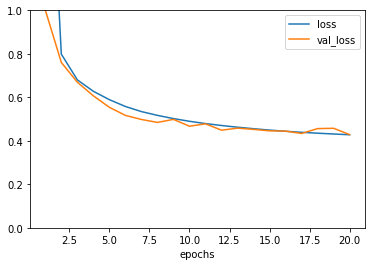

In [72]:
history.params.items
def print_history_reg(history):
    niter=history.params['epochs']
    print(history.history.keys())
    iter=np.arange(niter)+1
    plt.plot(iter,history.history['loss'],label='loss')
    plt.plot(iter,history.history['val_loss'],label='val_loss')
    plt.xlabel('epochs')
    plt.legend()
    plt.gca().set_ylim(0, 1)
print_history_reg(history)

We can use a pandas dataframe to do other manipulations

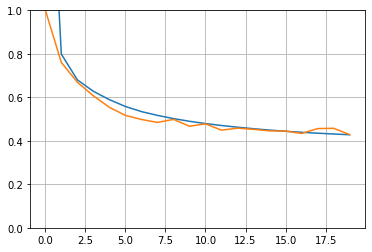

In [73]:
import pandas as pd
plt.plot(pd.DataFrame(history.history))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

We can now evaluate how it performs in the test data set.

In [74]:
mse_test = model.evaluate(X_test, y_test)
nsamples=10 # set the number of samples.
X_new = X_test[:nsamples]
y_new = y_test[:nsamples]
mse_new = model.evaluate(X_new, y_new)
y_pred = model.predict(X_new)
print('predicted',np.round(y_pred.T,2))
print('true      ',np.round(y_new,2))

10/10 [==============================] - 0s 159us/sample - loss: 0.5891
predicted [[0.68 1.65 3.22 2.53 2.7  1.89 2.74 1.8  2.87 4.09]]
true       [0.48 0.46 5.   2.19 2.78 1.59 1.98 1.58 3.4  4.47]


In [75]:
print(mse_test)

0.41963892338811887


Let us save the model and restore to a new instance of model.

In [76]:
model.save("my_keras_model.h5")

In [78]:
ls

10_neural_nets_with_keras.ipynb  my_keras_weights.ckpt.data-00000-of-00002
checkpoint                       my_keras_weights.ckpt.data-00001-of-00002
images/                          my_keras_weights.ckpt.index
my_keras_model.h5                Practice17_DNN.ipynb


In [77]:
model2 = keras.models.load_model("my_keras_model.h5")

In [79]:
mse_new = model.evaluate(X_new, y_new)
mse_new2 = model2.evaluate(X_new, y_new)
y_pred2 = model2.predict(X_new)
print('predicted',np.round(y_pred.T,2))
print('true      ',np.round(y_pred2.T,2))

10/10 [==============================] - 0s 6ms/sample - loss: 0.5891
predicted [[0.68 1.65 3.22 2.53 2.7  1.89 2.74 1.8  2.87 4.09]]
true       [[0.68 1.65 3.22 2.53 2.7  1.89 2.74 1.8  2.87 4.09]]


### Exercise 6: Regression with complex dataflow
Use the functional API for the housing data set, and the examples seeing in the lecture to create the "wide and deep NN"  with 2 inputs and 2 outputs

We will arbitrarily create 2 data sets A and B, with features 0-4 for A and 2-8 for B

In [80]:
X_train_A, X_train_B = X_train[:, :5], X_train[:, 2:]
X_valid_A, X_valid_B = X_valid[:, :5], X_valid[:, 2:]
X_test_A, X_test_B = X_test[:, :5], X_test[:, 2:]
X_new_A, X_new_B = X_test_A[:3], X_test_B[:3]
print(X_train_A.shape, X_valid_A.shape, X_test_A.shape)
print(X_train_B.shape, X_valid_B.shape, X_test_B.shape)

(11610, 5) (3870, 5) (5160, 5)
(11610, 6) (3870, 6) (5160, 6)


In [81]:
input_A = keras.layers.Input(shape=[5], name="wide_input")
input_B = keras.layers.Input(shape=[6], name="deep_input")
hidden1 = keras.layers.Dense(30, activation="relu")(input_B)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.concatenate([input_A, hidden2])
output = keras.layers.Dense(1, name="main_output")(concat)
aux_output = keras.layers.Dense(1, name="aux_output")(hidden2)
model = keras.models.Model(inputs=[input_A, input_B],
                           outputs=[output, aux_output])

In [82]:
model.compile(loss=["mse", "mse"], loss_weights=[0.9, 0.1], optimizer=keras.optimizers.SGD(lr=1e-3))

In [83]:
history = model.fit([X_train_A, X_train_B], [y_train, y_train], epochs=5,
                    validation_data=([X_valid_A, X_valid_B], [y_valid, y_valid]))

Train on 11610 samples, validate on 3870 samples
Epoch 1/5
11610/11610 [==============================] - 2s 142us/sample - loss: 2.6431 - main_output_loss: 2.3082 - aux_output_loss: 5.6490 - val_loss: 2.3821 - val_main_output_loss: 2.1532 - val_aux_output_loss: 4.4353
Epoch 2/5
11610/11610 [==============================] - 1s 99us/sample - loss: 1.0461 - main_output_loss: 0.7552 - aux_output_loss: 3.6628 - val_loss: 1.0910 - val_main_output_loss: 0.8094 - val_aux_output_loss: 3.6233
Epoch 3/5
11610/11610 [==============================] - 1s 99us/sample - loss: 0.8125 - main_output_loss: 0.6335 - aux_output_loss: 2.4226 - val_loss: 0.8824 - val_main_output_loss: 0.5925 - val_aux_output_loss: 3.4887
Epoch 4/5
11610/11610 [==============================] - 1s 94us/sample - loss: 0.7158 - main_output_loss: 0.5930 - aux_output_loss: 1.8198 - val_loss: 0.8507 - val_main_output_loss: 0.5606 - val_aux_output_loss: 3.4590
Epoch 5/5
11610/11610 [==============================] - 1s 95us/sampl

### Exercise 7: Using CallBacks
Use a "callback" function to save the model at the end of each epoch, but only save if the model is the best so far in the iterations.

"callbacks" are pieces of executable code that is passed as an argument to other code, which is expected to execute the code at some predefined time.

In [84]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [85]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[8]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])    

To use a callback, you need:
* create the instance of the class you choose from "keras.callbacks".
* include the callbacks argument in modelfit.

Notice, you can include more than one callback in "fit"

In [86]:
model.compile(loss="mse", optimizer=keras.optimizers.SGD(lr=1e-3))
checkpoint_cb = keras.callbacks.ModelCheckpoint("my_keras_model.h5", save_best_only=True)
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid),
                    callbacks=[checkpoint_cb])
model = keras.models.load_model("my_keras_model.h5") # rollback to best model
mse_test = model.evaluate(X_test, y_test)

Train on 11610 samples, validate on 3870 samples
Epoch 1/10
11610/11610 [==============================] - 1s 97us/sample - loss: 1.8423 - val_loss: 5.2165
Epoch 2/10
11610/11610 [==============================] - 1s 69us/sample - loss: 0.6876 - val_loss: 0.7732
Epoch 3/10
11610/11610 [==============================] - 1s 68us/sample - loss: 0.5954 - val_loss: 0.5446
Epoch 4/10
11610/11610 [==============================] - 1s 68us/sample - loss: 0.5553 - val_loss: 0.5425
Epoch 5/10
11610/11610 [==============================] - 1s 67us/sample - loss: 0.5268 - val_loss: 0.5539
Epoch 6/10
11610/11610 [==============================] - 1s 68us/sample - loss: 0.5049 - val_loss: 0.4701
Epoch 7/10
11610/11610 [==============================] - 1s 68us/sample - loss: 0.4852 - val_loss: 0.4562
Epoch 8/10
11610/11610 [==============================] - 1s 70us/sample - loss: 0.4706 - val_loss: 0.4452
Epoch 9/10
11610/11610 [==============================] - 1s 68us/sample - loss: 0.4576 - val_l

In [88]:
!ls -lat

total 764
-rw-rw-r--.  1 dtrad dtrad  23304 Nov  4 14:00 my_keras_model.h5
drwxrwxr-x.  4 dtrad dtrad   4096 Nov  4 14:00 .
-rw-rw-r--.  1 dtrad dtrad 226465 Nov  4 14:00 Practice17_DNN.ipynb
-rw-r--r--.  1 dtrad dtrad 495172 Nov  2 12:06 10_neural_nets_with_keras.ipynb
-rw-rw-r--.  1 dtrad dtrad     99 Nov  2 11:52 checkpoint
-rw-rw-r--.  1 dtrad dtrad    736 Nov  2 11:52 my_keras_weights.ckpt.index
-rw-rw-r--.  1 dtrad dtrad   4944 Nov  2 11:52 my_keras_weights.ckpt.data-00001-of-00002
-rw-rw-r--.  1 dtrad dtrad   1198 Nov  2 11:52 my_keras_weights.ckpt.data-00000-of-00002
drwxrwxr-x. 38 dtrad dtrad   4096 Oct 27 10:03 ..
drwxrwxr-x.  2 dtrad dtrad   4096 Oct 27 08:42 .ipynb_checkpoints
drwxrwxr-x.  3 dtrad dtrad     24 Aug 18 15:18 images


dict_keys(['loss', 'val_loss'])


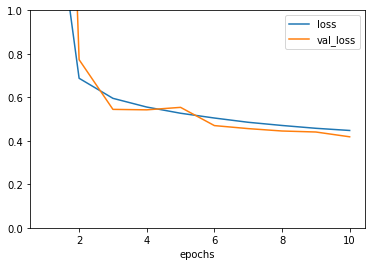

In [89]:
print_history_reg(history)

### Exercise 8: Using tensorboard
Save the history into a directory and visualize with tensorboard.

To save the data and visualize with tensorboard we need:
* create a unique directory 
* create a tensorboard callback
* run the network with the callback

In [90]:
root_logdir = os.path.join(os.curdir, "my_logs")
def get_run_logdir():
    import time
    run_id = time.strftime("run_%Y_%m_%d-%H_%M_%S")
    return os.path.join(root_logdir, run_id)

run_logdir = get_run_logdir()
run_logdir

'./my_logs/run_2020_11_04-14_02_07'

In [92]:
!ls
print('\n')
ls my_logs

SyntaxError: invalid syntax (<ipython-input-92-ea5f6b05dd4c>, line 3)

In [ ]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[8]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])    
model.compile(loss="mse", optimizer=keras.optimizers.SGD(lr=1e-3))

In [93]:
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)
history = model.fit(X_train, y_train, epochs=30,
                    validation_data=(X_valid, y_valid),
                    callbacks=[checkpoint_cb, tensorboard_cb])

Train on 11610 samples, validate on 3870 samples
Epoch 1/30
11610/11610 [==============================] - 1s 105us/sample - loss: 0.4385 - val_loss: 0.4287
Epoch 2/30
11610/11610 [==============================] - 1s 86us/sample - loss: 0.4319 - val_loss: 0.4117
Epoch 3/30
11610/11610 [==============================] - 1s 84us/sample - loss: 0.4252 - val_loss: 0.3975
Epoch 4/30
11610/11610 [==============================] - 1s 84us/sample - loss: 0.4199 - val_loss: 0.3943
Epoch 5/30
11610/11610 [==============================] - 1s 84us/sample - loss: 0.4150 - val_loss: 0.3964
Epoch 6/30
11610/11610 [==============================] - 1s 84us/sample - loss: 0.4110 - val_loss: 0.3907
Epoch 7/30
11610/11610 [==============================] - 1s 85us/sample - loss: 0.4070 - val_loss: 0.3823
Epoch 8/30
11610/11610 [==============================] - 1s 86us/sample - loss: 0.4036 - val_loss: 0.3786
Epoch 9/30
11610/11610 [==============================] - 1s 83us/sample - loss: 0.4003 - val_

To start the TensorBoard server, one option is to open a terminal, if needed activate the virtualenv where you installed TensorBoard, go to this notebook's directory, then type:

```bash
$ tensorboard --logdir=./my_logs --port=6006
```

You can then open your web browser to [localhost:6006](http://localhost:6006) and use TensorBoard. Once you are done, press Ctrl-C in the terminal window, this will shutdown the TensorBoard server.

Alternatively, you can load TensorBoard's Jupyter extension and run it like this:

In [94]:
%load_ext tensorboard
%tensorboard --logdir=./my_logs --port=6006

Reusing TensorBoard on port 6006 (pid 27941), started 2 days, 2:20:22 ago. (Use '!kill 27941' to kill it.)